In [1]:
# Импорт необходимых библиотек
from src.pdb.PDBFile import PDBFile
from tqdm import tqdm
from src.preprocessing.interpolation import resample_trajectory, resample_trajectory_cubic_spline
from src.preprocessing.curves import get_invariant_features
import numpy as np
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import torch
import torch.nn.functional as F
import warnings
import os
from sklearn.model_selection import train_test_split
from src.utils.config_loader import project_config
warnings.filterwarnings('ignore')
import tempfile
from Bio.PDB import PDBParser, DSSP



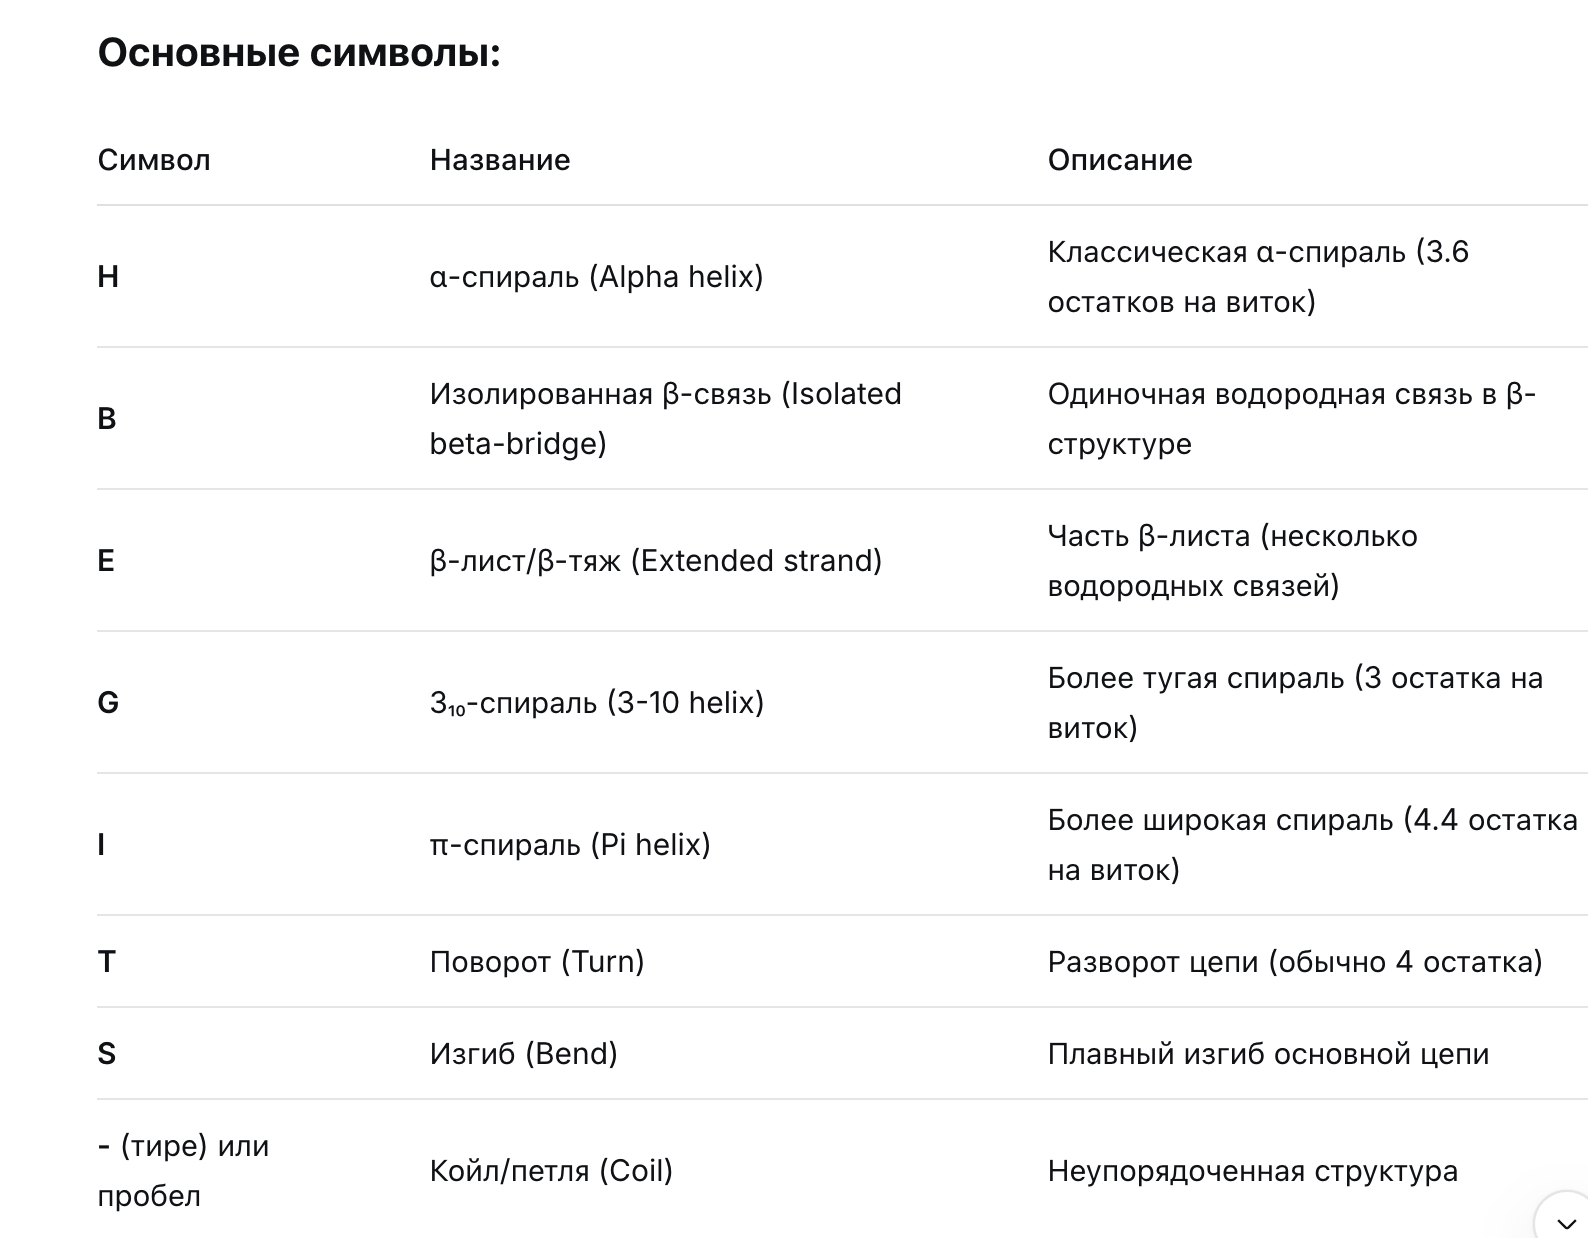

In [2]:
from concurrent.futures import ProcessPoolExecutor, as_completed
import tempfile
import os
from Bio.PDB import PDBParser, DSSP
from tqdm import tqdm

def extract_secondary_structure(pdb_path):
    with tempfile.NamedTemporaryFile(mode='w', suffix='.pdb', delete=False) as tmp:
        with open(pdb_path, 'r') as f:
            content = f.read()
        tmp.write("HEADER\n")
        tmp.write(content)
        tmp_path = tmp.name
    
    try:
        p = PDBParser()
        structure = p.get_structure("protein", tmp_path)
        model = structure[0]
        dssp = DSSP(model, tmp_path)
        
        ss_string = ""
        amino_string = ""
        
        for key in sorted(dssp.keys()):
            data = dssp[key]
            amino_string += data[1]  
            ss_string += data[2]
        
        alpha_helix = ss_string.count('H')/len(ss_string) if ss_string else 0
        beta_sheet = ss_string.count('E')/len(ss_string) if ss_string else 0
        
        return ss_string, amino_string, alpha_helix, beta_sheet
        
    except Exception as e:
        print(f"Error processing {pdb_path}: {e}")
        return "", "", 0, 0
    finally:
        if os.path.exists(tmp_path):
            os.unlink(tmp_path)

In [3]:
# # Загрузка данных
# K = 2048
# CA_POINT_ARRAY = []
# features = []
# import os
# counter = 100
# zero_error_count = 0
# for root, dirs, files in os.walk('data/new_dompdb/dompdb'):
#     for file in tqdm(files):
#         if counter == 0:
#             break
#         counter -= 1
#         file_path = os.path.join(root, file)
#         pdb_file = PDBFile(file_path)
#         _, _, alpha_helix, c = extract_secondary_structure(file_path)

        
#         if len(pdb_file.atom_line) > 0:
#             ca_point = pdb_file.get_point_cloud()
#             CA_POINT_ARRAY.append(ca_point)
#             features.append([alpha_helix,alpha_helix])

#         else: 
#             zero_error_count += 1

In [4]:
from concurrent.futures import ProcessPoolExecutor, as_completed
import os
from tqdm import tqdm

def process_file(file_info):
    root, file = file_info
    file_path = os.path.join(root, file)
    
    try:
        pdb_file = PDBFile(file_path)
        _, _, alpha_helix, beta_sheet = extract_secondary_structure(file_path)
        
        if len(pdb_file.atom_line) > 0:
            ca_point = pdb_file.get_point_cloud()
            return {
                'ca_point': ca_point,
                'features': [alpha_helix, beta_sheet],
                'error': False
            }
        else:
            return {'error': True, 'type': 'zero_atoms'}
            
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return {'error': True, 'type': 'exception'}

def calculate_feature_and_ca():
    K = 2048
    CA_POINT_ARRAY = []
    features = []
    zero_error_count = 0
    exception_error_count = 0
    
    all_files = []
    for root, dirs, files in os.walk('data/new_dompdb/dompdb'):
        for file in files:
            all_files.append((root, file))
    
    max_workers = min(os.cpu_count() or 4, len(all_files))
    
    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        future_to_file = {
            executor.submit(process_file, file_info): file_info 
            for file_info in all_files
        }
        
        with tqdm(total=len(all_files), desc="Processing PDB files") as pbar:
            for future in as_completed(future_to_file):
                result = future.result()
                
                if result['error']:
                    if result['type'] == 'zero_atoms':
                        zero_error_count += 1
                    else:
                        exception_error_count += 1
                else:
                    CA_POINT_ARRAY.append(result['ca_point'])
                    features.append(result['features'])
                
                pbar.update(1)
    
    print(f"Processed {len(CA_POINT_ARRAY)} files successfully")
    print(f"Zero atom errors: {zero_error_count}")
    print(f"Exception errors: {exception_error_count}")
    
    return CA_POINT_ARRAY, features

CA_POINT_ARRAY, features = calculate_feature_and_ca()

Processing PDB files:   5%|▊              | 6545/119369 [01:20<23:30, 80.00it/s]

Error processing data/new_dompdb/dompdb/1bdp002.pdb: DSSP failed to produce an output


Processing PDB files:  38%|█████▎        | 45561/119369 [09:39<15:41, 78.41it/s]

Error processing data/new_dompdb/dompdb/1alo006.pdb: DSSP failed to produce an output


Processing PDB files:  54%|███████▌      | 64618/119369 [13:44<11:19, 80.53it/s]

...

Error processing data/new_dompdb/dompdb/1gep001.pdb: DSSP failed to produce an output


Processing PDB files:  95%|████████████▎| 113061/119369 [24:06<01:19, 78.97it/s]

Error processing data/new_dompdb/dompdb/1baa001.pdb: DSSP failed to produce an output


Processing PDB files: 100%|█████████████| 119369/119369 [25:26<00:00, 78.18it/s]


Processed 119369 files successfully
Zero atom errors: 0
Exception errors: 0


In [5]:
resampled_coords = []
failed_indices = []  
new_feature = []

for idx, example in enumerate(tqdm(CA_POINT_ARRAY)):
    try:
        invariant_features = get_invariant_features(np.array(example))
        
        if len(invariant_features) < 4:
            print(f"Пример {idx}: недостаточно точек ({len(invariant_features)}) для сплайна, пропускаем")
            failed_indices.append((idx, "Недостаточно точек"))
            continue
            
        resampled = resample_trajectory_cubic_spline(invariant_features, k=2048)
        
        if resampled is not None and len(resampled) == 2048:
            resampled_coords.append(resampled)
            new_feature.append(features[idx])
        else:
            print(f"Пример {idx}: некорректный результат ресемплинга")
            failed_indices.append((idx, "Некорректный результат"))
            
    except ValueError as e:
        print(f"Пример {idx}: ValueError - {e}")
        failed_indices.append((idx, f"ValueError: {e}"))
    except Exception as e:
        print(f"Пример {idx}: неожиданная ошибка - {type(e).__name__}: {e}")
        failed_indices.append((idx, f"{type(e).__name__}: {e}"))

 38%|█████████████▎                     | 45376/119369 [06:58<11:06, 110.95it/s]

Пример 45353: ValueError - x_i должны быть строго возрастающими


 41%|██████████████▍                    | 49306/119369 [07:34<10:37, 109.96it/s]

Пример 49285: ValueError - x_i должны быть строго возрастающими


 72%|█████████████████████████▎         | 86447/119369 [13:15<04:54, 111.68it/s]

Пример 86430: ValueError - x_i должны быть строго возрастающими


100%|██████████████████████████████████| 119369/119369 [18:17<00:00, 108.72it/s]


In [6]:
config = project_config.load()  

train_data_raw, val_data_raw, train_features, val_features = train_test_split(
    resampled_coords,  new_feature,      
    test_size=config.get('training', {}).get('validation_split', 0.1),  
    random_state=42 
)

In [7]:
train_data_raw[0]

array([[ 29.01416983,  -5.35024357,   4.93605283],
       [ 28.95042932,  -5.18584088,   5.29049967],
       [ 28.88908325,  -5.02090747,   5.64094816],
       ...,
       [-11.86512263, -12.6149531 ,   0.42980282],
       [-12.0370232 , -12.29014153,   0.27502136],
       [-12.21030174, -11.96054437,   0.12123169]], shape=(2048, 3))

In [15]:
train_features[6]

[0.5555555555555556, 0.0]

In [43]:
train_features[0]

[0.453416149068323, 0.15527950310559005]

In [44]:
class CVAETrajectoriesDataset(Dataset):
    def __init__(self, trajectories, features, normalize=False):
        if isinstance(trajectories[0], torch.Tensor):
            self.dataset = torch.stack(trajectories)
        else:
            self.dataset = torch.tensor(np.array(trajectories), dtype=torch.float32)
        self.normalize = normalize
        self.features = features

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        trajectory = self.dataset[idx]

        if self.normalize:
            trajectory_norm = trajectory.clone()
            
            min_val = torch.min(trajectory_norm)
            max_val = torch.max(trajectory_norm)
            
            scale = max_val - min_val
            
            if scale > 1e-6: 
                trajectory_norm = (trajectory_norm - min_val) / scale
            else:
                trajectory_norm = torch.zeros_like(trajectory_norm)
            
            trajectory_norm = trajectory_norm.permute(1, 0)
            return trajectory_norm, torch.tensor(self.features[idx]), trajectory_norm
        else:
            trajectory = trajectory.permute(1, 0)
            return trajectory, torch.tensor(self.features[idx]), trajectory

In [45]:
train_dataset = CVAETrajectoriesDataset(train_data_raw, train_features, normalize = True)
val_dataset = CVAETrajectoriesDataset(val_data_raw, val_features, normalize = True)

In [46]:
train_dataset[0]

(tensor([[0.9612, 0.9600, 0.9589,  ..., 0.1931, 0.1898, 0.1866],
         [0.3155, 0.3186, 0.3217,  ..., 0.1790, 0.1851, 0.1913],
         [0.5088, 0.5154, 0.5220,  ..., 0.4241, 0.4212, 0.4183]]),
 tensor([0.4534, 0.1553]),
 tensor([[0.9612, 0.9600, 0.9589,  ..., 0.1931, 0.1898, 0.1866],
         [0.3155, 0.3186, 0.3217,  ..., 0.1790, 0.1851, 0.1913],
         [0.5088, 0.5154, 0.5220,  ..., 0.4241, 0.4212, 0.4183]]))

In [47]:
# Настройка устройства
device = config.get('model', {}).get('device', 'cpu')
print(f'DEVICE LEARNING: {device}')
learning_rate = config.get('training', {}).get('learning_rate', 0.1)
num_epochs = config.get('training', {}).get('epochs', 100)
batch_size = config.get('training', {}).get('batch_size', 16)

DEVICE LEARNING: cuda


In [48]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [49]:
# Проверка train

In [59]:
import torch
import torch.nn.functional as F
import numpy as np
from tqdm import tqdm


def train_vae(
    model, 
    train_loader, 
    val_loader, 
    num_epochs=100,
    device='cuda',
    lr=1e-3,
    patience=10,
    beta_start=0.001,  # Начальное значение beta для KL-дивергенции
    beta_end=0.01,     # Конечное значение beta
    warmup_epochs=10   # Количество эпох для постепенного увеличения beta
):
    """
    Улучшенная функция обучения VAE
    
    Основные улучшения:
    1. Постепенное увеличение веса KL-дивергенции (beta) в начале обучения
    2. Лучшая обработка размерностей
    3. Добавлена ранняя остановка
    4. Более информативный вывод
    """
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    
    history = {
        'train_loss': [],
        'val_loss': [],
        'train_recon': [],
        'val_recon': [],
        'train_kl': [],
        'val_kl': [],
        'beta_values': []  # Для отслеживания изменения beta
    }
    
    best_val_loss = float('inf')
    patience_counter = 0
    
    for epoch in range(num_epochs):
        # Рассчитываем текущее значение beta
        if epoch < warmup_epochs:
            # Линейное увеличение beta в течение первых warmup_epochs
            beta = beta_start + (beta_end - beta_start) * (epoch / warmup_epochs)
        else:
            beta = beta_end
        
        # ===== TRAINING =====
        model.train()
        train_losses = []
        train_recon_losses = []
        train_kl_losses = []
        
        for batch_idx, batch in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Training")):
            x, conditions, _ = batch
            
            x = x.to(device)
            conditions = conditions.to(device)
            
            optimizer.zero_grad()
            
            recon_x, mu, logvar = model(x, conditions)
            
            # Проверяем размерности
            if recon_x.shape != x.shape:
                print(f"Размерности не совпадают: recon_x {recon_x.shape}, x {x.shape}")
                continue
            
            # Реконструкционная ошибка
            recon_loss = F.mse_loss(recon_x, x, reduction='sum') / x.size(0)
            
            # KL-дивергенция
            kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
            
            # Общий лосс
            loss = recon_loss + beta * kl_loss
            
            loss.backward()
            
            # Градиентный клиппинг для стабилизации обучения
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            
            train_losses.append(loss.item())
            train_recon_losses.append(recon_loss.item())
            train_kl_losses.append(kl_loss.item())
        
        if not train_losses:
            print("Нет данных для обучения, пропускаем эпоху")
            continue
            
        # Средние значения за эпоху
        avg_train_loss = np.mean(train_losses)
        avg_train_recon = np.mean(train_recon_losses)
        avg_train_kl = np.mean(train_kl_losses)
        
        history['train_loss'].append(avg_train_loss)
        history['train_recon'].append(avg_train_recon)
        history['train_kl'].append(avg_train_kl)
        
        # ===== VALIDATION =====
        model.eval()
        val_losses = []
        val_recon_losses = []
        val_kl_losses = []
        
        with torch.no_grad():
            for batch in val_loader:
                x, conditions, _ = batch
                x = x.to(device)
                conditions = conditions.to(device)
                recon_x, mu, logvar = model(x, conditions)
                
                
                # Проверяем размерности
                if recon_x.shape != x.shape:
                    continue
                
                recon_loss = F.mse_loss(recon_x, x, reduction='sum') / x.size(0)
                kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
                
                loss = recon_loss + beta * kl_loss
                
                val_losses.append(loss.item())
                val_recon_losses.append(recon_loss.item())
                val_kl_losses.append(kl_loss.item())
        
        if not val_losses:
            print("Нет данных для валидации, пропускаем эпоху")
            continue
            
        avg_val_loss = np.mean(val_losses)
        avg_val_recon = np.mean(val_recon_losses)
        avg_val_kl = np.mean(val_kl_losses)
        
        history['val_loss'].append(avg_val_loss)
        history['val_recon'].append(avg_val_recon)
        history['val_kl'].append(avg_val_kl)
        history['beta_values'].append(beta)
        
        # Обновляем learning rate на основе валидационной ошибки
        scheduler.step(avg_val_loss)
        
        print(f'Epoch {epoch+1}/{num_epochs}:')
        print(f'  Beta: {beta:.4f}')
        print(f'  Train: Loss={avg_train_loss:.4f}, Recon={avg_train_recon:.4f}, KL={avg_train_kl:.4f}')
        print(f'  Val:   Loss={avg_val_loss:.4f}, Recon={avg_val_recon:.4f}, KL={avg_val_kl:.4f}')
        
        # Ранняя остановка
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            # Сохраняем лучшую модель
            torch.save(model.state_dict(), 'best_vae_model.pth')
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Ранняя остановка на эпохе {epoch+1}")
                break
    
    # Загружаем лучшую модель
    model.load_state_dict(torch.load('best_vae_model.pth'))
    
    return history, model

In [60]:
from src.models.conditional_vae import ConditionalImprovedConv1DVAE

In [61]:
model = ConditionalImprovedConv1DVAE(latent_dim = 128)

In [62]:
next(iter(train_loader))

[tensor([[[0.0222, 0.0234, 0.0247,  ..., 0.3404, 0.3478, 0.3552],
          [0.1728, 0.1799, 0.1869,  ..., 0.6653, 0.6672, 0.6690],
          [0.5693, 0.5665, 0.5638,  ..., 0.7603, 0.7586, 0.7568]],
 
         [[0.0000, 0.0060, 0.0119,  ..., 0.7414, 0.7429, 0.7446],
          [0.8040, 0.7982, 0.7925,  ..., 0.8715, 0.8755, 0.8795],
          [0.5595, 0.5559, 0.5525,  ..., 0.2528, 0.2463, 0.2398]],
 
         [[0.7129, 0.7108, 0.7087,  ..., 0.9964, 0.9982, 1.0000],
          [0.1501, 0.1527, 0.1553,  ..., 0.3552, 0.3541, 0.3531],
          [0.4762, 0.4729, 0.4695,  ..., 0.2981, 0.2946, 0.2911]],
 
         ...,
 
         [[0.9940, 0.9948, 0.9955,  ..., 0.5239, 0.5269, 0.5299],
          [0.3473, 0.3457, 0.3441,  ..., 0.2547, 0.2549, 0.2550],
          [0.1988, 0.2019, 0.2049,  ..., 0.3172, 0.3189, 0.3207]],
 
         [[0.7106, 0.7166, 0.7225,  ..., 0.0235, 0.0161, 0.0087],
          [0.0930, 0.0970, 0.1010,  ..., 0.2137, 0.2129, 0.2121],
          [0.5556, 0.5535, 0.5513,  ..., 0.5314,

In [63]:
# Обучение модели
history, trained_model = train_vae(
    model,
    train_loader,
    val_loader,
    num_epochs=num_epochs,
    device=device,
    lr=learning_rate,
    patience=1000,
    beta_start=0.001,
    beta_end=0.01,
    warmup_epochs=15
)

Epoch 1/200 - Training: 100%|███████████████| 3358/3358 [02:02<00:00, 27.39it/s]


Epoch 1/200:
  Beta: 0.0010
  Train: Loss=30.7940, Recon=29.7140, KL=1079.9834
  Val:   Loss=11.8801, Recon=11.3086, KL=571.5119


Epoch 2/200 - Training: 100%|███████████████| 3358/3358 [02:02<00:00, 27.31it/s]


Epoch 2/200:
  Beta: 0.0016
  Train: Loss=9.9948, Recon=9.2234, KL=482.0992
  Val:   Loss=11.3036, Recon=10.5627, KL=463.0355


Epoch 3/200 - Training: 100%|███████████████| 3358/3358 [02:03<00:00, 27.23it/s]


...

Epoch 41/200:
  Beta: 0.0100
  Train: Loss=3659.4309, Recon=3.4565, KL=365597.4318
  Val:   Loss=256.9584, Recon=254.7041, KL=225.4332


Epoch 42/200 - Training: 100%|██████████████| 3358/3358 [02:03<00:00, 27.14it/s]


Epoch 42/200:
  Beta: 0.0100
  Train: Loss=5.6051, Recon=3.3002, KL=230.4832
  Val:   Loss=583.7408, Recon=9.3231, KL=57441.7731


Epoch 43/200 - Training:  68%|█████████▌    | 2292/3358 [01:24<00:39, 27.15it/s]


KeyboardInterrupt: 